<a href="https://colab.research.google.com/github/Karthikeyanvenugopalan/3-DOF-Manipulator-sim/blob/main/model/data_prep_model_train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HAR with CSI data: Model creation
### Necessary Imports

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls "/content/drive/MyDrive"

'10th-Science-New-Book-EM - www.tntextbooks.in.pdf'
'10th தமிழ் கட்டுரை மற்றும் கடிதம் _kalviexpress.pdf'
 2014_question_paper.pdf
 2015_question_paper.pdf
 2016_question_paper.pdf
 2017_question_paper.pdf
 2018_question_paper.pdf
'Advanced Problem in Mathematics By Vikas Gupta (www.jeebooks.in).pdf'
 Classroom
'Colab Notebooks'
 csi_data
'Getting started.pdf'
 IMG-20250928-WA0006.jpg
'nmms mat_ part-1 karkandukanitham Ganesh.gdoc'
 Paper-MAT-v1.pdf
 RCS_PROJECT.pdf
 Screencastify
 Std10-Tamil-www.tntextbooks.in.pdf
'Untitled folder'
'Untitled form.gform'
'Untitled Jam.pdf'


In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns
import math, os, pickle
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from collections import Counter
import random

random.seed(42)
np.random.seed(42)

In [21]:
column_names = [
"type","role","mac","rssi","rate","sig_mode","mcs","bandwidth","smoothing",
"not_sounding","aggregation","stbc","fec_coding","sgi","noise_floor",
"ampdu_cnt","channel","secondary_channel","local_timestamp","ant","sig_len",
"rx_state","len","CSI_DATA"
]

df = pd.read_csv(
    "/content/drive/MyDrive/csi_data/aaj_jog.csv",
    names=column_names,
    header=None
)

print(df.head())
print(df.columns)

                           type  role  mac  rssi  rate  sig_mode  mcs  \
CSI_DATA STA  AC:0B:FB:26:85:8D   -86   11     0     0         0    0   
         STA  AC:0B:FB:26:85:8D   -83   11     0     0         0    0   
         STA  AC:0B:FB:26:85:8D   -82   11     0     0         0    0   
         STA  AC:0B:FB:26:85:8D   -85   11     0     0         0    0   
         STA  AC:0B:FB:26:85:8D   -86   11     0     0         0    0   

              bandwidth  smoothing  not_sounding  ...  noise_floor  ampdu_cnt  \
CSI_DATA STA          0          0             0  ...            6          1   
         STA          0          0             0  ...            6          1   
         STA          0          0             0  ...            6          1   
         STA          0          0             0  ...            6          1   
         STA          0          0             0  ...            6          1   

              channel  secondary_channel  local_timestamp  ant  sig_len  \

### Create dataframes for each activity

In [22]:
def dataframe_of_CSI(directory):

    df_walk = pd.DataFrame()
    df_noact = pd.DataFrame()
    df_jog = pd.DataFrame()

    for file in os.listdir(directory):

        if file.endswith(".csv") and ("walk" in file or "noact" in file or "jog" in file):

            file_path = os.path.join(directory, file)

            df = pd.read_csv(file_path, on_bad_lines='skip')
            df = df.iloc[::2]

            csi_column = df.columns[-1]

            csi_rows_raw = []

            for one_row in df[csi_column].iloc[40:-40]:

                if isinstance(one_row, str):

                    one_row = one_row.strip("[]")

                    values = []
                    for x in one_row.replace(',', ' ').split():
                     try:
                         values.append(int(x))
                     except:
                          continue

                    if len(values) > 50:
                        csi_rows_raw.append(values)

            csi_df = pd.DataFrame(csi_rows_raw)

            if "walk" in file.lower():
                df_walk = pd.concat([df_walk, csi_df], ignore_index=True)

            elif "noact" in file.lower():
                df_noact = pd.concat([df_noact, csi_df], ignore_index=True)

            elif "jog" in file.lower():
                df_jog = pd.concat([df_jog, csi_df], ignore_index=True)

    return df_walk, df_noact, df_jog

# Example pseudo-code
def parse_csi_csv(df, label):
    """Converts raw CSI CSV into standard format with 'sig_mode', 'label', 'csi_vector'"""
    parsed_rows = []
    for idx, row in df.iterrows():
        csi_vector = row.iloc[-1]  # assuming last column has CSI array
        parsed_rows.append({
            "sig_mode": 1,          # or whatever mode your ESP32 used
            "label": label,
            "csi_vector": csi_vector
        })
    return pd.DataFrame(parsed_rows)

In [23]:
# Path to your CSI CSV files in Google Drive
directory = "/content/drive/MyDrive/dataset"

# List files (optional check)
print(os.listdir(directory))

# Create DataFrames
walk_df, noact_df, jog_df = dataframe_of_CSI(directory)

# Quick check
print("Walk shape:", walk_df.shape)
print("No Activity shape:", noact_df.shape)
print("Jog shape:", jog_df.shape)

['walk_data_1.csv', 'walk_data_2.csv', 'walk_data_3.csv', 'noactivity_1.csv', 'noactivity_2.csv', 'noactivity_3.csv', 'jog_sanj_1.csv', 'jog_sanj_2.csv', 'jog_sanj_3.csv', 'noactivity_k1.csv', 'noactivity_k2.csv', 'walk_k2.csv', 'jog_k1 (1).csv', 'jog_k1.csv', 'jog_k2.csv', 'jog_m1.csv', 'jog_m2.csv', 'labels.npy', 'walk_k1.csv']
Walk shape: (7604, 761)
No Activity shape: (6153, 877)
Jog shape: (12301, 696)


In [24]:
print(len(walk_df),len(noact_df),len(jog_df))

7604 6153 12301


### Extact Amplitude and Phase from each dataframe

In [25]:
## Extract Amplitude and Phase from the dataframe
def convert_csi_to_amplitude_phase(df):
    total_amplitudes = []
    total_phases = []

    for i, value in enumerate(df.values):
        imaginary = []
        real = []
        amplitudes = []
        phases = []

        csi_one_row_lst = value.tolist()

         # Create list of imaginary and real numbers from CSI
        [imaginary.append(csi_one_row_lst[item]) if item%2==0 else real.append(csi_one_row_lst[item]) for item in range(len(csi_one_row_lst))]

        # Transform imaginary and real into amplitude and phase
        val = int(len(csi_one_row_lst)//2)
        for k in range(val):
            amplitudes.append(round(math.sqrt(float(imaginary[k])** 2 + float(real[k])** 2),4))
            phases.append(round(math.atan2(float(imaginary[k]), float(real[k])),4))
        total_amplitudes.append(np.array(amplitudes))
        total_phases.append(np.array(phases))

    total_amplitudes_df = pd.DataFrame(total_amplitudes)
    total_phases_df = pd.DataFrame(total_phases)


    return total_amplitudes_df, total_phases_df

### Amplitude and Phase of Walking

In [26]:
## Extract walk amplitude and phase
walk_amplitudes_df, walk_phases_df = convert_csi_to_amplitude_phase(walk_df)

## Here, based on sig_mode, 802.11a/g/n received. Here we receive both 802.11a/g and 802.11n
## So, either 52 or 56 total sub-carrier would be useful. The first 4 and the last 4 are rejected as null guard.


## Amplitude
walk_df1_amps = walk_amplitudes_df.iloc[:,5:32]  # 6:32 for 802.11ag 4:32 for 802.11n
walk_df2_amps = walk_amplitudes_df.iloc[:,33:60] # 33:59 for 802.11ag 33:61 for 802.11n

walk_df_amps_final = pd.concat([walk_df1_amps, walk_df2_amps],axis=1)


## Phase
walk_df1_phase = walk_amplitudes_df.iloc[:,5:32]  # 6:32 for 802.11ag 4:32 for 802.11n
walk_df2_phase = walk_amplitudes_df.iloc[:,33:60] # 33:59 for 802.11ag 33:61 for 802.11n

walk_df_phase_final = pd.concat([walk_df1_phase, walk_df2_phase],axis=1)

### Amplitude and Phase of Jogging

In [27]:
## Extract jog amplitude and phase
jog_amplitudes_df, jog_phases_df = convert_csi_to_amplitude_phase(jog_df)

## Amplitude
jog_df1_amps = jog_amplitudes_df.iloc[:,5:32]  # 6:32 for 802.11ag 4:32 for 802.11n
jog_df2_amps = jog_amplitudes_df.iloc[:,33:60] # 33:59 for 802.11ag 33:61 for 802.11n

jog_df_amps_final = pd.concat([jog_df1_amps, jog_df2_amps],axis=1)


## Phase
jog_df1_phase = jog_amplitudes_df.iloc[:,5:32]  # 6:32 for 802.11ag 4:32 for 802.11n
jog_df2_phase = jog_amplitudes_df.iloc[:,33:60] # 33:59 for 802.11ag 33:61 for 802.11n

jog_df_phase_final = pd.concat([jog_df1_phase, jog_df2_phase],axis=1)

### Amplitude and Phase of No Activity

In [28]:
## Extract jog amplitude and phase
noact_amplitudes_df, noact_phases_df = convert_csi_to_amplitude_phase(noact_df)

## Amplitude
noact_df1_amps = noact_amplitudes_df.iloc[:,5:32]  # 6:32 for 802.11ag 4:32 for 802.11n
noact_df2_amps = noact_amplitudes_df.iloc[:,33:60] # 33:59 for 802.11ag 33:61 for 802.11n

noact_df_amps_final = pd.concat([noact_df1_amps, noact_df2_amps],axis=1)


## Phase
noact_df1_phase = noact_amplitudes_df.iloc[:,5:32]  # 6:32 for 802.11ag 4:32 for 802.11n
noact_df2_phase = noact_amplitudes_df.iloc[:,33:60] # 33:59 for 802.11ag 33:61 for 802.11n

noact_df_phase_final = pd.concat([noact_df1_phase, noact_df2_phase],axis=1)

#### Moving Average of the data

In [29]:
# Moving average of the data
def moving_average(df, window_size):
    """"
    Compute the moving average with a window of size specified
    """

    rolling_mean = df.rolling(window=window_size).mean()
    downsampled = rolling_mean.iloc[window_size::window_size, :]
    return downsampled


## Set moving average window of desired size
window_size = 1
mov_avg_walk_amps_df = moving_average(walk_df_amps_final,window_size)
mov_avg_jog_amps_df = moving_average(jog_df_amps_final,window_size)
mov_avg_noact_amps_df = moving_average(noact_df_amps_final,window_size)


### Select data matrix and flatten it for training

In [30]:
def select_data_portion(dataFrm,select_size):
    selected_df_list = []
    for item in range(0,len(dataFrm)-select_size, select_size):
        selected_df = dataFrm.iloc[item:item+select_size].to_numpy().flatten()
        selected_df_list.append(selected_df)
    selected_df = pd.DataFrame(selected_df_list)
    return selected_df

In [31]:
X_walk = select_data_portion(mov_avg_walk_amps_df, 100)
X_jog = select_data_portion(mov_avg_jog_amps_df, 100)
X_noact = select_data_portion(mov_avg_noact_amps_df, 100)
X_training = pd.concat([X_walk, X_jog, X_noact], axis=0, ignore_index=True)
# X_training

In [32]:

y_walk = np.zeros(len(X_walk))
y_jog = np.ones(len(X_jog))
y_noact = np.full(len(X_noact), 2)
y_training = np.concatenate([y_walk, y_jog, y_noact], axis=0)

In [33]:
X_training

,0,1,2,3,4,5,6,7,8,9,...,5390,5391,5392,5393,5394,5395,5396,5397,5398,5399
0,1580.5316,1073.1566,932.0569,724.8724,1040.5470,231.8642,894.7357,529.1597,791.2749,903.3327,...,24806.0466,29573.2455,28924.2393,32393.6363,25510.3055,21573.0000,696.0359,3877.0889,5151.4052,7720.7939
1,1622.8016,2843.8330,1290.5131,3060.8922,3672.9511,2618.9773,1937.1838,3824.2025,2400.4727,2418.8371,...,23541.6495,29573.2455,28924.2393,1547.7212,811.7567,3431.2266,1275.8440,3299.0297,3166.7892,1550.2993
2,9397.9796,8850.4717,8508.2868,8667.0081,9061.6707,7591.5834,7588.6701,7228.7529,6879.8565,7070.6314,...,1039.7932,594.0135,827.0580,799.4229,1160.4034,1276.0333,1569.9914,562.0053,1390.9224,2664.0145
3,4587.7666,3455.5823,4943.7367,2583.6970,1354.7878,2086.8579,2972.6789,1424.1131,1468.7171,1793.5197,...,2405.2214,3609.0921,3303.6029,4758.8288,2766.8598,5768.1776,5849.7508,6444.0038,6932.1842,8586.5258
4,3427.8496,3114.4801,2881.4602,3429.2619,2156.6775,1830.2333,2882.1676,1796.0518,2711.9117,2547.2000,...,8585.1762,9216.0450,8496.2983,11574.5713,9257.1778,10301.9051,9930.7419,9772.6519,9211.2505,8626.1116
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
254,4006.1424,4191.7006,2358.4684,2859.0366,2917.9805,3476.8319,1950.8216,3838.0001,3841.2015,3617.5586,...,1490.4070,1326.7347,1083.0905,2443.2053,3277.4406,1311.4099,788.2290,1032.2136,2936.4536,1829.2887
255,5262.0590,4568.2918,4387.9997,4398.9277,6316.2560,4600.6848,4698.0177,5749.2800,4602.3477,4224.5059,...,8228.6394,8833.7791,9814.1470,10947.3446,9622.5712,11661.1408,11276.7386,11801.4508,12155.7959,13972.2438
256,5253.9498,6204.4573,6896.2794,6199.6297,6415.3416,7607.0553,4358.0644,7438.9167,5244.9317,5396.5341,...,5607.1887,3793.0001,5316.9244,5464.0144,6516.1941,5427.6773,5080.7568,8341.1319,5421.6604,6373.8002
257,2189.9107,2738.2505,2551.2417,1733.4027,2431.1069,2577.2041,2937.5338,2306.2840,2686.6315,2430.2597,...,24806.0466,29573.2455,28924.2393,32393.6363,25510.3055,21573.0000,3095.3321,3477.8593,4101.0044,4165.3515


## Training and Testing pipeline using sklearn

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_training, y_training, test_size=0.2, random_state=42
)
X_train

,0,1,2,3,4,5,6,7,8,9,...,5390,5391,5392,5393,5394,5395,5396,5397,5398,5399
211,3626.0758,2167.4642,3598.0667,2718.2320,2128.3914,1968.0554,2290.8797,783.0926,891.9849,364.4448,...,7028.9434,6844.8535,7140.2379,6354.2015,6565.4346,8286.8426,7274.7933,4001.9751,6107.3891,5350.3661
141,707.8142,1130.1195,1040.9995,904.7187,1261.0016,553.7156,498.1446,341.5333,342.2426,1045.7251,...,5293.1945,6372.2339,5991.8868,6716.3997,6904.5337,6905.7979,7619.7832,7800.1740,9983.3423,8887.3475
115,1562.9466,4541.8767,4012.6779,4571.9921,3493.0849,6006.9810,3447.5699,3848.8003,5438.3605,2923.0590,...,23541.6495,29573.2455,28924.2393,3463.0832,4736.4632,4994.0634,1829.2963,4897.3647,4898.4128,4369.0001
77,283.5913,794.3626,790.4277,1125.0071,1317.6012,1333.7226,2204.7594,1322.8605,1522.0713,1302.8112,...,23541.6495,29573.2455,28924.2393,2501.0656,1674.6597,878.3997,1606.9676,3746.6414,4672.5618,4250.4995
181,388.2023,386.0829,947.4371,831.4451,1167.6994,1107.3292,943.2736,527.1859,1072.0392,741.0479,...,7087.5583,7275.1727,6022.7284,6189.2142,6186.6393,6375.6965,7459.5231,6353.1662,6175.2619,5261.9412
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20,7248.5525,6176.5079,6172.1900,5984.2628,5256.8243,6111.2900,5086.8969,4973.4021,4171.5556,3446.8049,...,10178.3788,11426.0927,10870.6891,14477.3043,12325.6101,14667.6992,14118.4940,12674.1820,13313.4041,13939.6643
188,7766.8658,5980.6027,6134.8586,7225.7365,6335.0760,5952.9499,5233.5759,5422.9743,5231.4803,4875.3802,...,9071.4255,9240.8858,8907.5649,8316.2836,6870.2495,8323.6387,7775.3820,5598.9701,4873.9670,4185.2987
71,1148.4459,1285.4019,1722.2198,2537.8063,2067.5350,1640.1381,2725.4570,2724.2338,4561.0964,2180.0103,...,2087.6410,2312.1116,593.9428,586.4640,564.0257,1031.6560,889.7640,1812.2210,1258.2289,1609.2237
106,6044.6135,6356.9761,6162.3074,6193.9648,5611.7372,6336.8486,5268.3524,5476.2565,4258.7666,4341.6356,...,2073.7488,3143.9817,3865.0032,1805.1000,2088.3776,4721.3520,2439.2673,5855.6312,3690.3725,3849.8053


In [35]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.impute import SimpleImputer

# Fill NaN values in features
imputer = SimpleImputer(strategy='mean')
X_train_clean = imputer.fit_transform(X_train)
X_test_clean = imputer.transform(X_test)

# Reshape y to 2D
y_train_reshaped = y_train.reshape(-1, 1)
y_test_reshaped = y_test.reshape(-1, 1)

# Fill missing labels if any
imputer_y = SimpleImputer(strategy='most_frequent')
Y_train_clean = imputer_y.fit_transform(y_train_reshaped)
Y_test_clean = imputer_y.transform(y_test_reshaped)

# Convert back to 1D
Y_train_clean = Y_train_clean.ravel()
Y_test_clean = Y_test_clean.ravel()

# RandomForest Classifier


In [48]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create Random Forest model
rfmodel = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# Train model
rfmodel.fit(X_train_clean, Y_train_clean)

# Predict
y_pred_rf = rfmodel.predict(X_test_clean)

# Evaluation
print("Random Forest Accuracy:", accuracy_score(Y_test_clean, y_pred_rf))
print(confusion_matrix(Y_test_clean, y_pred_rf))
print(classification_report(Y_test_clean, y_pred_rf))

Random Forest Accuracy: 0.4230769230769231
[[ 2 14  4]
 [ 2 19  1]
 [ 2  7  1]]
              precision    recall  f1-score   support

         0.0       0.33      0.10      0.15        20
         1.0       0.47      0.86      0.61        22
         2.0       0.17      0.10      0.12        10

    accuracy                           0.42        52
   macro avg       0.33      0.35      0.30        52
weighted avg       0.36      0.42      0.34        52



### SVM Classifier


In [53]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=100)),
    ('svc', SVC())
])

pipe.fit(X_train_clean, Y_train_clean)

y_pred = pipe.predict(X_test_clean)

print("SVM Accuracy:", accuracy_score(Y_test_clean, y_pred))
print(confusion_matrix(Y_test_clean, y_pred))
print(classification_report(Y_test_clean, y_pred))

SVM Accuracy: 0.6153846153846154
[[12  6  2]
 [ 3 17  2]
 [ 2  5  3]]
              precision    recall  f1-score   support

         0.0       0.71      0.60      0.65        20
         1.0       0.61      0.77      0.68        22
         2.0       0.43      0.30      0.35        10

    accuracy                           0.62        52
   macro avg       0.58      0.56      0.56        52
weighted avg       0.61      0.62      0.61        52



### KNN Classifier

In [60]:
pipe2 = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=20)),
    ('knn', KNeighborsClassifier())
])

pipe2.fit(X_train_clean, Y_train_clean)

y_pred_knn = pipe2.predict(X_test_clean)

print("KNN Accuracy:", accuracy_score(Y_test_clean, y_pred_knn))
print(confusion_matrix(Y_test_clean, y_pred_knn))
print(classification_report(Y_test_clean, y_pred_knn))

KNN Accuracy: 0.6346153846153846
[[12  5  3]
 [ 2 20  0]
 [ 4  5  1]]
              precision    recall  f1-score   support

         0.0       0.67      0.60      0.63        20
         1.0       0.67      0.91      0.77        22
         2.0       0.25      0.10      0.14        10

    accuracy                           0.63        52
   macro avg       0.53      0.54      0.51        52
weighted avg       0.59      0.63      0.60        52



### Save Model

In [61]:

# path in Google Drive
model_params = "/content/drive/MyDrive/Wifi-Sensing-HAR/data_real/model_params"

# create folder if it does not exist
os.makedirs(model_params, exist_ok=True)

# save models
pickle.dump(pipe, open(f"{model_params}/pipe_final_svm.pkl", "wb"))
pickle.dump(pipe2, open(f"{model_params}/pipe_final_knn.pkl", "wb"))

print("Models saved successfully!")

# load model (example)
loaded_model = pickle.load(open(f"{model_params}/pipe_final_svm.pkl", "rb"))

print("Model loaded successfully!")

Models saved successfully!
Model loaded successfully!


-------
Training and Testing Pipeline ends here

# **Testing from the trained model**


In [62]:
import pickle

model = pickle.load(open("/content/drive/MyDrive/Wifi-Sensing-HAR/data_real/model_params/pipe_final_svm.pkl","rb"))

In [70]:
rows = []

with open("/content/drive/MyDrive/dataset/walk_data_1.csv", "r") as f:
    for line in f:
        parts = line.strip().split(",")

        # If row has less than expected columns → skip
        if len(parts) < 24:
            continue

        # First 23 columns = metadata
        meta = parts[:23]

        # Rest = CSI_DATA (merge back)
        csi_data = ",".join(parts[23:])

        rows.append(meta + [csi_data])

        df = pd.DataFrame(rows, columns=column_names)

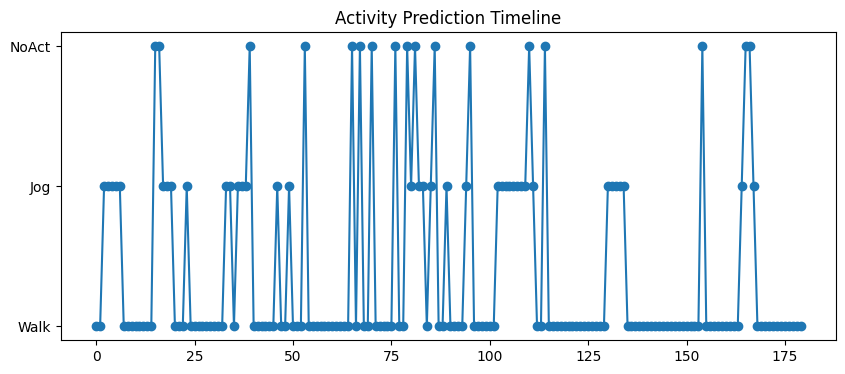

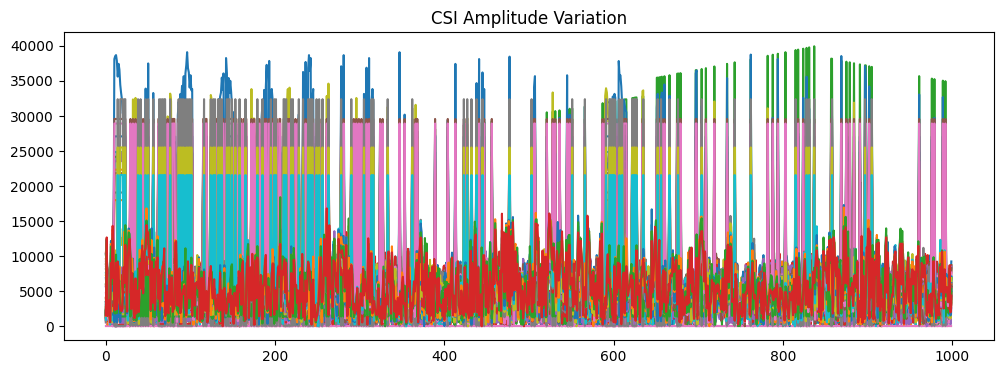

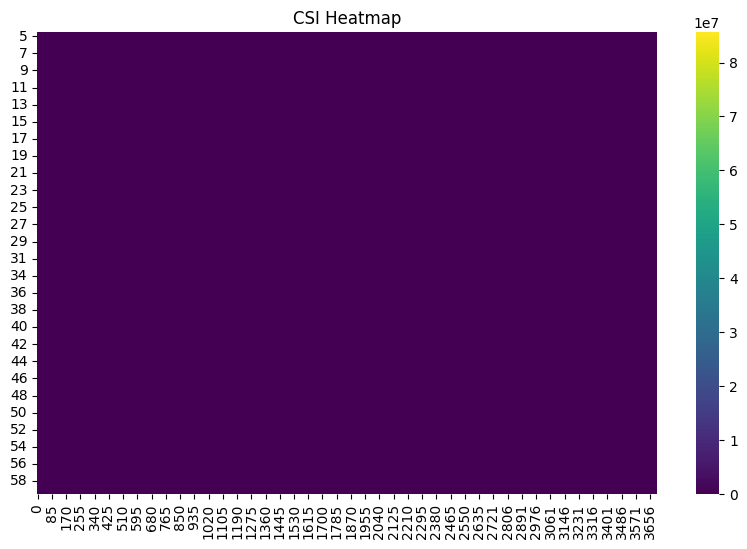


Final Detected Activity: Walk


In [74]:
import re
import math
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

# ---------- Convert CSI to amplitude ----------
def convert_csi_to_amplitude(df):

    amplitudes = []

    for row in df["CSI_DATA"].iloc[40:-40]:

        row = str(row).strip("[]")

        values = list(map(int, re.findall(r'-?\d+', row)))

        real = []
        imag = []

        for i, v in enumerate(values):
            if i % 2 == 0:
                real.append(v)
            else:
                imag.append(v)

        amp = []
        for i in range(min(len(real), len(imag))):
            amp.append(math.sqrt(real[i]**2 + imag[i]**2))

        amplitudes.append(amp)

    return pd.DataFrame(amplitudes)

# ---------- Windowing ----------
def select_windows(data, size=100, step=20):

    windows = []

    for i in range(0, len(data)-size, step):
        win = data.iloc[i:i+size].to_numpy().flatten()
        windows.append(win)

    return pd.DataFrame(windows)

# ---------- Convert CSI ----------
amps = convert_csi_to_amplitude(df)

# ---------- Select subcarriers ----------
amps = pd.concat([amps.iloc[:,5:32], amps.iloc[:,33:60]], axis=1)

# ---------- Remove bad rows (VERY IMPORTANT) ----------
amps = amps.replace([np.inf, -np.inf], np.nan)
amps = amps.dropna()   # removes rows with NaN

# ---------- Windowing ----------
X_test = select_windows(amps, 100)

# ---------- Handle NaN before model ----------
imputer = SimpleImputer(strategy='mean')
X_test_clean = imputer.fit_transform(X_test)

# ---------- Predict ----------
pred = model.predict(X_test_clean)   # or pipe.predict / rfmodel.predict

# ---------- Labels ----------
labels = ["Walk", "Jog", "NoAct"]

# ---------- Plot 1 ----------
plt.figure(figsize=(10,4))
plt.plot(pred, marker='o')
plt.yticks([0,1,2], labels)
plt.title("Activity Prediction Timeline")
plt.show()

# ---------- Plot 2 ----------
plt.figure(figsize=(12,4))
plt.plot(amps.iloc[:1000])
plt.title("CSI Amplitude Variation")
plt.show()

# ---------- Plot 3 ----------
plt.figure(figsize=(10,6))
sns.heatmap(amps.T, cmap="viridis")
plt.title("CSI Heatmap")
plt.show()

# ---------- Final Activity ----------
final_activity = labels[int(Counter(pred).most_common(1)[0][0])]
print("\nFinal Detected Activity:", final_activity)